### EDA absentismo laboral (dataset RRHH)

In [31]:
"""
Carga de datos
"""
from EDA_helpers import load_tables, categorizar_ausentismo

# Importa todas las bibliotecas necesarias para este NoteBook
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt

tablas_db = ['ausentismo']

# Paleta de colores Seaborn Set2, para usarla con MatPlotLib y seguir el mismo estilo
sns_color_set2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
colores = sns_color_set2

df = load_tables(tablas_db)

# Extrae los dataframes del diccionario que devuelve `load_tables()`
for t in df:
    globals()[f'df_{t}'] = df[t]

Cargando los datos de la tabla ausentismo


In [32]:
# Categorizar las columnas Month_absence, Day_of_week y Season.
df_ausentismo = categorizar_ausentismo(df_ausentismo)
df_ausentismo.head()

,id,reason_id,absence_reason,justified,Absenteeism_hours,Month_absence_num,Month_absence,Day_week,Day_of_week,Season,...,Age,Education,Social_drinker,Social_smoker,children,pets,weight,height,bmi,Group
0,14,11,Diseases of the digestive system,1,120,11,November,2,Monday,Spring,...,34,1,1,0,2,0,95,196,25,26-35
1,36,13,Diseases of the musculoskeletal system and con...,1,120,4,April,4,Wednesday,Winter,...,50,1,1,0,1,0,98,178,31,46-54
2,9,6,Diseases of the nervous system,1,120,7,July,3,Tuesday,Summer,...,58,1,0,0,2,1,65,172,22,55-65
3,28,9,Diseases of the circulatory system,1,112,7,July,3,Tuesday,Summer,...,28,1,0,0,1,2,69,169,24,26-35
4,9,12,Diseases of the skin and subcutaneous tissue,1,112,3,March,3,Tuesday,Autumn,...,58,1,0,0,2,1,65,172,22,55-65


In [3]:
# Exportamos el DF a un archivo .csv para luego utilizarlo en los gráficos exploratorios.
df_ausentismo.to_csv('RRHH_20251120.csv')

#### Descripción estadística

In [4]:
#Resumen estadístico inicial
df_ausentismo.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,1106.0,78.991863,106.513742,1.000,14.000,28.000,108.750,386.000
reason_id,1106.0,19.163653,8.324058,0.000,13.000,23.000,26.000,28.000
justified,1106.0,0.904159,0.294506,0.000,1.000,1.000,1.000,1.000
Absenteeism_hours,1106.0,8.625678,18.039349,0.000,2.000,3.000,8.000,120.000
Month_absence_num,1106.0,6.356239,3.443617,1.000,3.000,6.000,10.000,12.000
Day_week,1106.0,3.912297,1.416928,2.000,3.000,4.000,5.000,6.000
tr_expense,1106.0,221.972875,67.153887,118.000,179.000,225.000,260.000,388.000
dist2work,1106.0,29.395118,14.805842,5.000,16.000,26.000,50.000,52.000
Service_time,1106.0,12.493671,4.391112,1.000,9.000,12.000,16.000,29.000
work_load_avg,1106.0,272.049706,39.163773,205.917,244.387,264.604,294.217,378.884


In [5]:
# Distribución de datos categóricos
df_ausentismo_cat = df_ausentismo.select_dtypes(exclude=np.number)
df_ausentismo_cat.describe().transpose()

,count,unique,top,freq
absence_reason,1106,28,medical consultation,213
Month_absence,1106,12,March,127
Day_of_week,1106,5,Tuesday,238
Season,1106,4,Spring,294
Group,1106,4,36-45,533


In [7]:
#Agrupar por 'absence_reason' para determinar los motivos más frecuentes de absentismo laboral.
df_ausencias_razon = df_ausentismo \
                        .groupby('absence_reason')['reason_id'] \
                        .count() \
                        .sort_values(ascending=False)
df_ausencias_razon

absence_reason
medical consultation                                                                                   213
dental consultation                                                                                    173
physiotherapy                                                                                           96
Diseases of the musculoskeletal system and connective tissue                                            88
Injury, poisoning and certain other consequences of external causes                                     65
Unknown                                                                                                 56
Patient fol-up                                                                                          56
unjustified absence                                                                                     50
laboratory examination                                                                                  44
Diseases of the digest

In [8]:
# Calcular el total de absentismo por Mes
total_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['id'].count()
total_por_mes

Month_absence
January       83
February     103
March        127
April         79
May          100
June          70
July         110
August        79
September     76
October      109
November      92
December      78
Name: id, dtype: int64

In [9]:
#Calcular la media de absentismo por mes

# 1. Calcular la media de Absenteeism_hours por Month_absence
media_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['Absenteeism_hours'].mean().reset_index()

# 2. Eliminar meses que no están presentes en los datos (si aplica) y ordenar
media_h_por_mes = media_por_mes.dropna(subset=['Month_absence'])

# 3. Formatear la media a dos decimales
media_h_por_mes['Absenteeism_hours'] = media_h_por_mes['Absenteeism_hours'].round(2)
media_h_por_mes

,Month_absence,Absenteeism_hours
0,January,3.92
1,February,4.17
2,March,13.38
3,April,12.75
4,May,7.11
5,June,9.36
6,July,14.48
7,August,5.51
8,September,6.41
9,October,5.22


In [ ]:
# Calcular el total de horas de ausentismo por Mes

# 1. Calcular el TOTAL de Absenteeism_hours por Month_absence
# Agrupamos por el mes y calculamos la SUMA de las horas de absentismo.
total_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['Absenteeism_hours'] \
                             .sum() \
                             .reset_index()


# Eliminar meses que no están presentes en los datos y ordenar el DataFrame
total_h_por_mes = total_por_mes.dropna(subset=['Month_absence'])
total_h_por_mes

,Month_absence,Absenteeism_hours
0,January,325
1,February,429
2,March,1699
3,April,1007
4,May,711
5,June,655
6,July,1593
7,August,435
8,September,487
9,October,569


### Visualizaciones EDA (df_ausentismo)
#### Visualización: Plots por variables Categóricas

In [ ]:
# Configuración básica para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Mejora de la resolución de los gráficos

# Distribución de datos categóricos
df_ausentismo_cat = df_ausentismo.select_dtypes(exclude=np.number)
df_ausentismo_cat.head()

,absence_reason,Month_absence,Day_of_week,Season,Group
0,Diseases of the digestive system,November,Monday,Spring,26-35
1,Diseases of the musculoskeletal system and con...,April,Wednesday,Winter,46-54
2,Diseases of the nervous system,July,Tuesday,Summer,55-65
3,Diseases of the circulatory system,July,Tuesday,Summer,26-35
4,Diseases of the skin and subcutaneous tissue,March,Tuesday,Autumn,55-65


Gráfico de barras de frecuencia de absentismo por mes


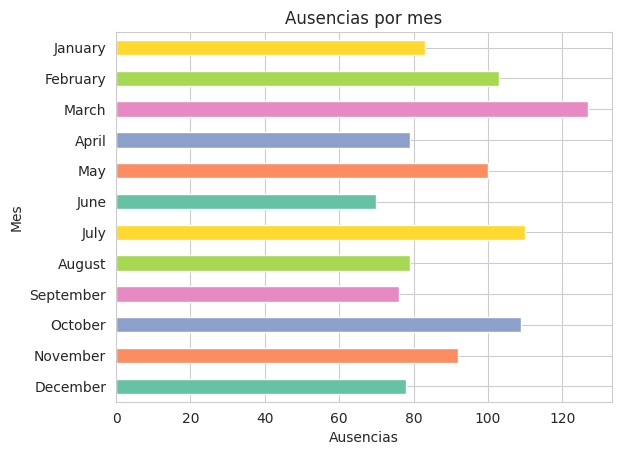

In [12]:
#Gráfico de barras de cantidad de ausentismo por mes

# Conteo por mes respetando el orden definido en lista_meses
(
	df_ausentismo_cat['Month_absence']
		.value_counts()
		.reindex(rmonths, fill_value=0)
		.plot.barh(color=sns_color_set2[0:6])
)

plt.title('Ausencias por mes')
plt.xlabel('Ausencias')
plt.ylabel('Mes');


Grafico de barras de frecuencia de absentismo por dias de la semana


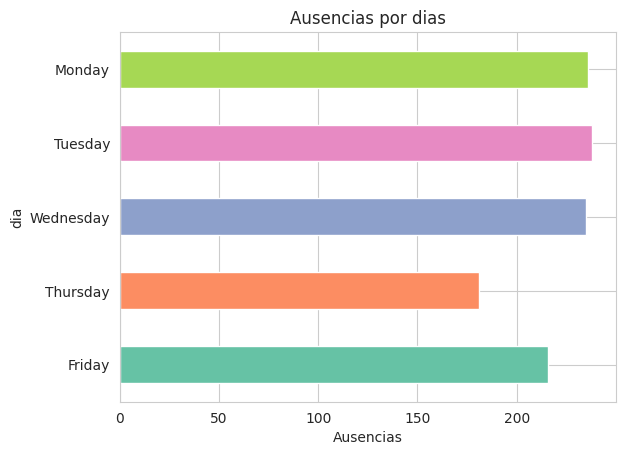

In [15]:
#Grafico de barras de absentismo por días

# Conteo por mes respetando el orden definido en lista_meses
(
	df_ausentismo_cat['Day_of_week']
	.value_counts()
	.reindex(rweekdays, fill_value=0)
	.plot.barh(color=sns_color_set2)
)

plt.title('Ausencias por dias')
plt.xlabel('Ausencias')
plt.ylabel('dia');


Gráfico de barras de frecuencia de absentismo por estaciones del año


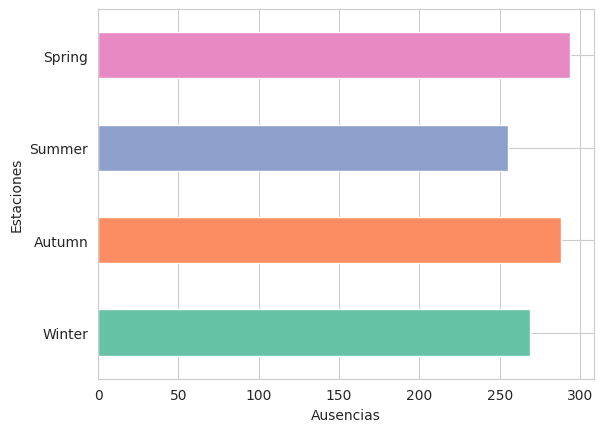

In [19]:
#Gráfico de barras de frecuencia de absentismo por estaciones del año
# Conteo por estación del año respetando el orden definido en temporada
(
	df_ausentismo_cat['Season']
	.value_counts()
	.reindex(rseasons, fill_value=0)
	.plot.barh(color=colores)
)

#plt.title('Ausencias por estaciones del año')
plt.xlabel('Ausencias')
plt.ylabel('Estaciones');

#### Visualizaciones por variables categóricas y numéricas

Gráfico de ausentismo por franja de edad


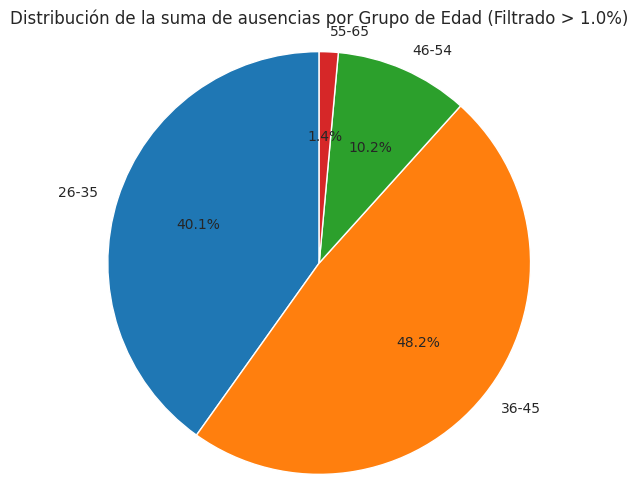

In [21]:
# Gráfico de ausentismo por edad

# --- PASO 1: Agrupar y Calcular Porcentajes ---
group_amounts = df_ausentismo.groupby('Group', observed=False)['id'].count()

# Calcular el total para obtener el porcentaje
total_ausencias = group_amounts.sum()
# Calcular los porcentajes
group_percentages = (group_amounts / total_ausencias) * 100

# --- PASO 2: Filtrar los grupos pequeños ---
# Definir un umbral de porcentaje (e.g., si es menor a 1.0%, lo quitamos)
UMBRAL_PORCENTAJE = 1.0 

# Crear una serie filtrada
# Solo incluimos los grupos cuyo porcentaje es mayor o igual al umbral
filtered_amounts = group_amounts[group_percentages >= UMBRAL_PORCENTAJE]
filtered_percentages = group_percentages[group_percentages >= UMBRAL_PORCENTAJE]


# --- PASO 3: Crear el Gráfico de Pie con los Datos Filtrados ---
plt.figure(figsize=(6 , 6)) # Aumentar ligeramente el tamaño para mejor visualización
plt.pie(filtered_amounts.values.tolist(),
        labels=filtered_amounts.index.tolist(),
        # Usamos 'autopct' solo para los datos filtrados
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.6
       )
plt.title('Distribución de la suma de ausencias por Grupo de Edad (Filtrado > 1.0%)')
plt.axis('equal') 
plt.show()

Gráfico de distribución del absentismo por categoría del nomenclador (ICD)

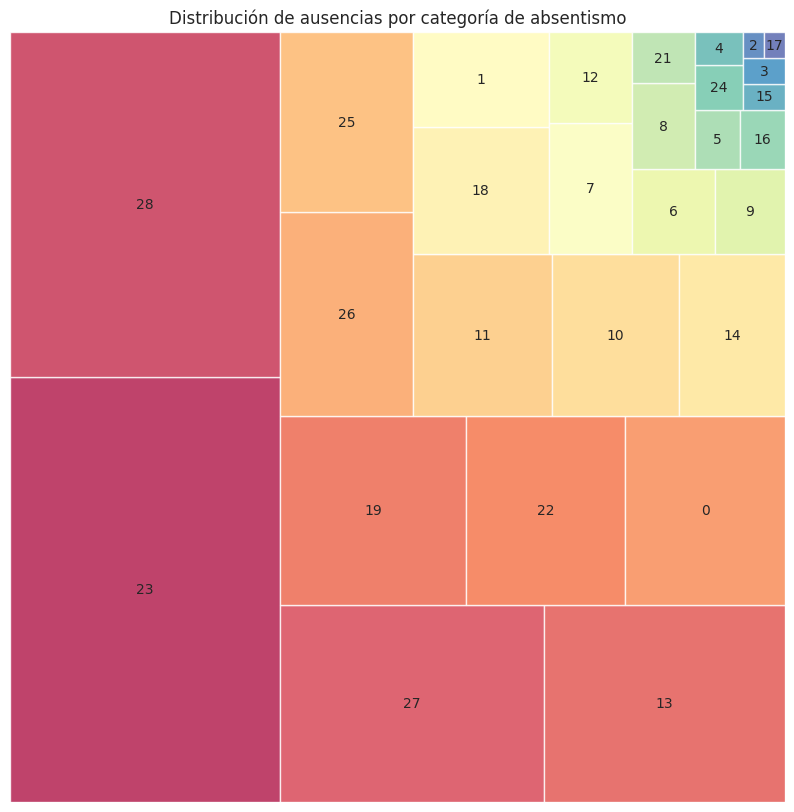

In [23]:
#Gráfico de la variable categórica 'absence_reason'
# %pip install squarify
import squarify
absence_counts = df_ausentismo['reason_id'].value_counts()

# create a figure
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()

squarify.plot(sizes=absence_counts.values, label=absence_counts.index, ax=ax, alpha=0.8,color=sns.color_palette("Spectral", 
                                     len(absence_counts.values)))
plt.title('Distribución de ausencias por categoría de absentismo')
plt.axis('off')
plt.show()

#### Visualización: temporalidad del absentismo


Gráfico de barras para cuantificar la cantidad media de horas de absentismo por mes.


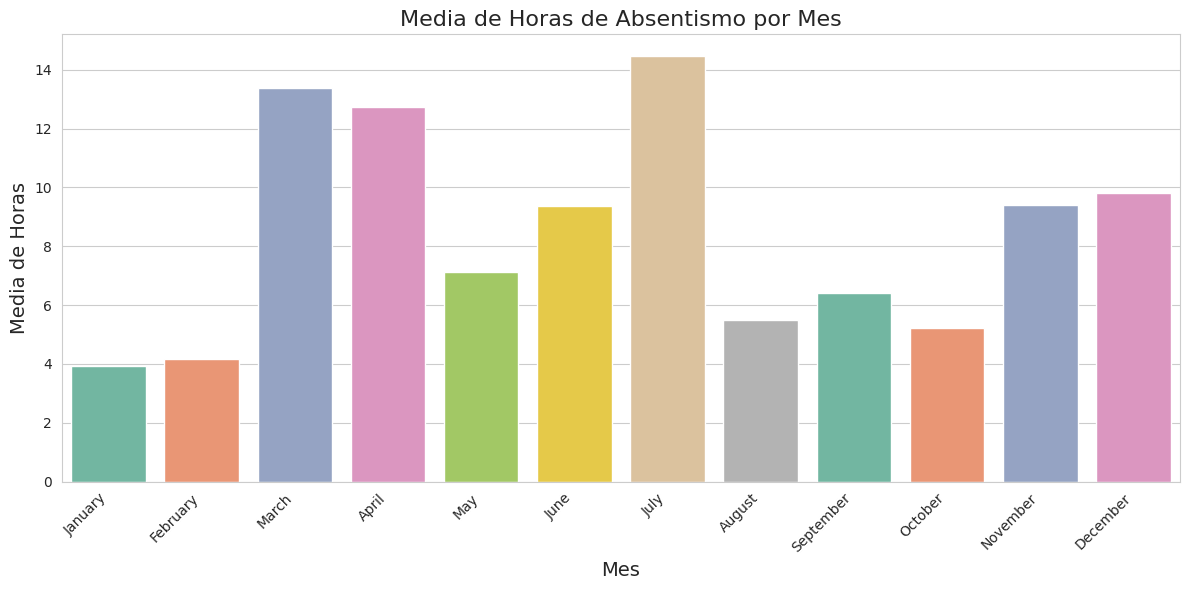

In [24]:
# Gráfico de barras para cuantificar la cantidad media de horas de absentismo por mes.
# Calcular la media de Absenteeism_hours por Month_absence
# Agrupamos por el mes de la ausencia y calculamos la media de las horas de absentismo.
media_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['Absenteeism_hours'].mean().reset_index()

# Eliminar meses que no están presentes en los datos
media_por_mes = media_por_mes.dropna(subset=['Month_absence'])

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Month_absence',
    y='Absenteeism_hours',
    data=media_por_mes,
    palette='Set2',
    hue='Month_absence',
    legend=False
)

# Añadir etiquetas y título
plt.title('Media de Horas de Absentismo por Mes', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Media de Horas', fontsize=14)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()

Gráfico del Total de Horas de Absentismo por Mes


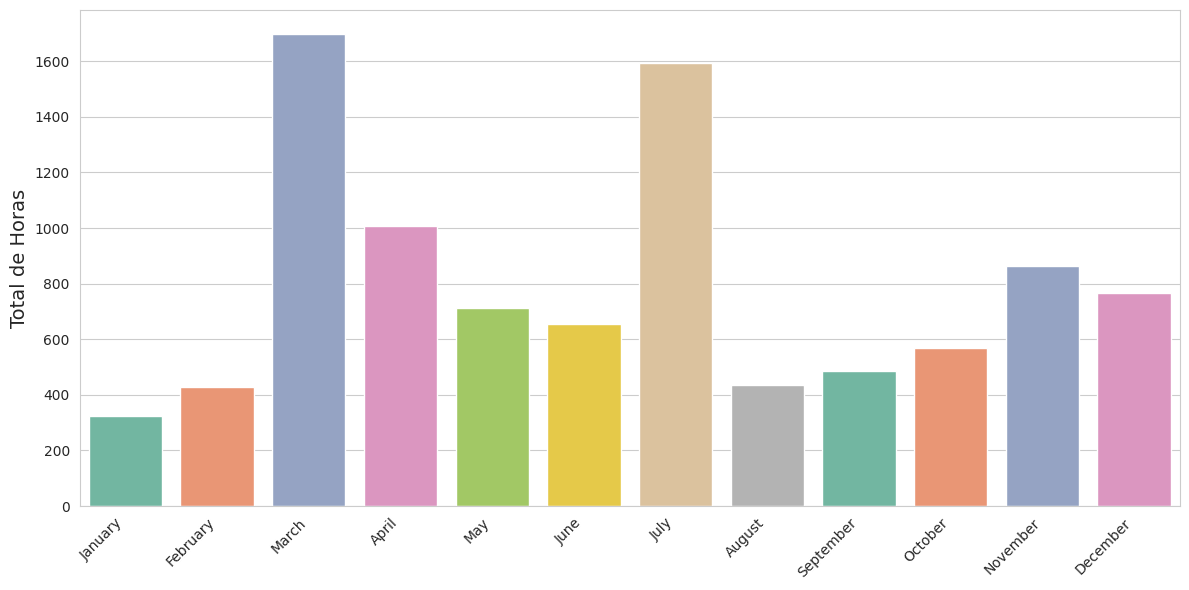

In [25]:
# Calcular el TOTAL de Absenteeism_hours por Month_absence
# Agrupamos por el mes y calculamos la SUMA de las horas de absentismo.
total_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['Absenteeism_hours'].sum().reset_index()

# Eliminar meses que no están presentes en los datos y ordenar el DataFrame
total_por_mes = total_por_mes.dropna(subset=['Month_absence'])

# 3. Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Month_absence',
    y='Absenteeism_hours',
    data=total_por_mes,
    palette='Set2',
    hue='Month_absence',
    legend=False
)

# Añadir etiquetas y título
#plt.title('Total de Horas de Absentismo por Mes', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Total de Horas', fontsize=14)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Gráfico de la media de horas de absentismo por día de la semana


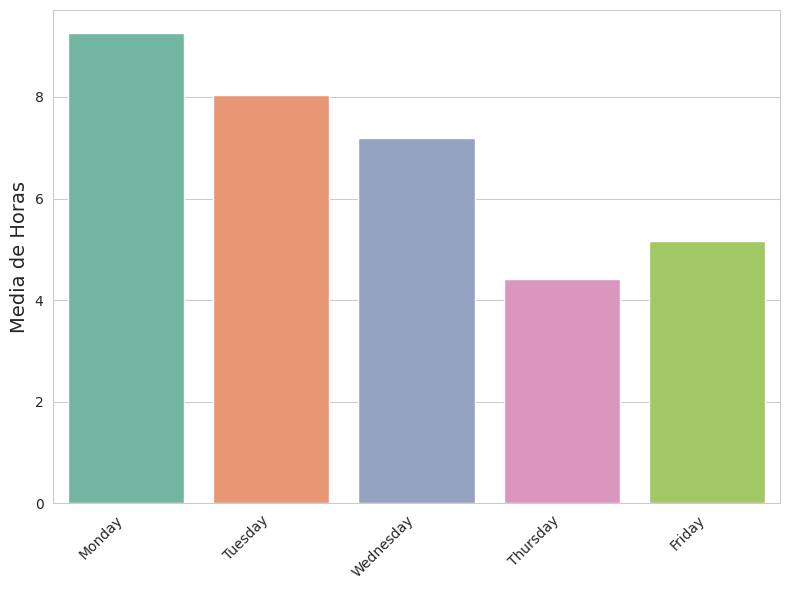

In [ ]:
# Gráfico de la media de horas de absentismo por día de la semana

# Reordenar los datos agregados por día. Agrupar por 'Day_of_week' y reindexar por 'order'.
df_plot = df_ausentismo.groupby('Day_of_week', observed=False)['Absenteeism_hours'].mean().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Day_of_week',
    y='Absenteeism_hours',
    data=df_plot,
    palette='Set2',
    hue='Day_of_week',
    legend=False
)

# Añadir etiquetas y título
#plt.title('Media de Horas de Absentismo por día', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Media de Horas', fontsize=14)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()

Gráfico de la suma de horas de absentismo por día de la semana


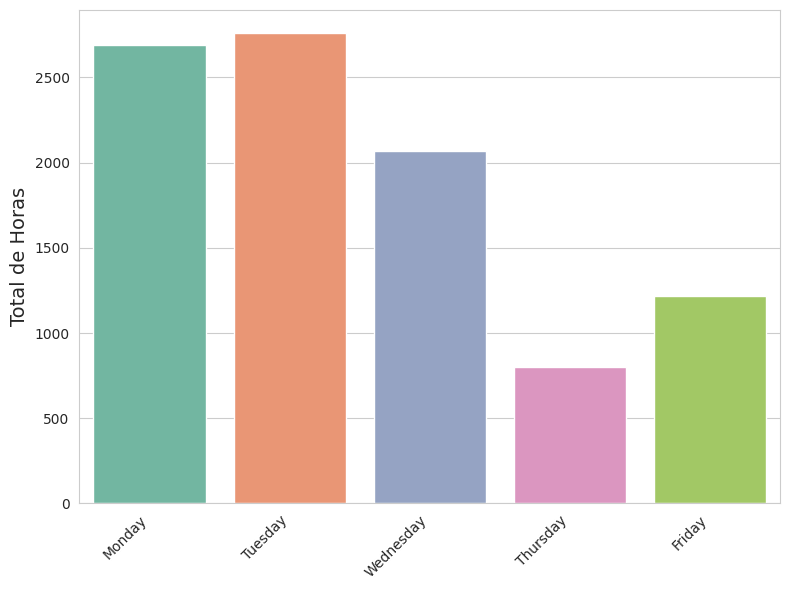

In [26]:
# Gráfico de la suma de horas de absentismo por día de la semana

# Reordenar los datos agregados por día. Agrupar por 'Day_of_week' y reindexar por 'order'.
df_plot = df_ausentismo.groupby('Day_of_week', observed=False)['Absenteeism_hours'].sum().reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Day_of_week',
    y='Absenteeism_hours',
    data=df_plot,
    palette='Set2',
    hue='Day_of_week',
    legend=False
)

# Añadir etiquetas y título
#plt.title('Media de Horas de Absentismo por día', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Total de Horas', fontsize=14)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()

#### Visualización: Correlación entre variables numéricas

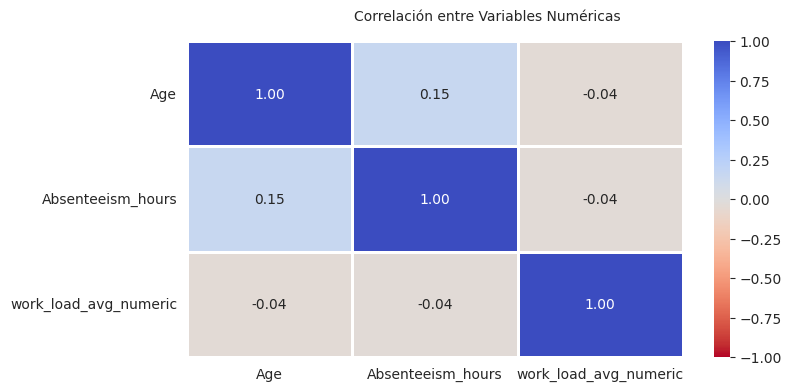

In [33]:
# Correlación de variables numéricas (Age, Absenteeism_hours, work_load_avg) con pandas .corr

# Convertir la columna work_load_avg a float
# Los valores vienen con separador de miles como coma (ej: '284,031'), los limpiamos antes de convertir
df_ausentismo['work_load_avg_numeric'] = pd.to_numeric(
    df_ausentismo['work_load_avg'].astype(str).str.replace(',', ''),
    errors='coerce'
)

# Calculamos la correlación entre las variables numéricas
correlation = df_ausentismo[['Age', 'Absenteeism_hours', 'work_load_avg_numeric']].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables Numéricas', fontsize=10)
plt.show()

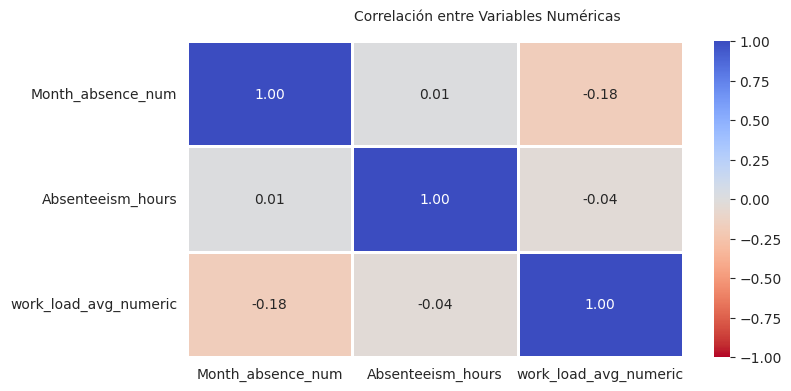

In [34]:
# Correlación de variables numéricas (Month_absence_num, Absenteeism_hours, work_load_avg) con pandas .corr

# Convertir la columna work_load_avg a float
# Los valores vienen con separador de miles como coma (ej: '284,031'), los limpiamos antes de convertir
df_ausentismo['work_load_avg_numeric'] = pd.to_numeric(
    df_ausentismo['work_load_avg'].astype(str).str.replace(',', ''),
    errors='coerce'
)

# Calculamos la correlación entre las variables numéricas
correlation = df_ausentismo[['Month_absence_num', 'Absenteeism_hours', 'work_load_avg_numeric']].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables Numéricas', fontsize=10)
plt.show()